
**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [13]:
import pandas as pd

medical_df = pd.read_csv('medical-charges.csv')

medical_df.head(5)

# 1. Проаналізувати чи є кореляція між категоріальною і числовою змінною, знайти закономірності.
# 2. Визначити середнє за групами (курці - не курці, вікові групи, категоріями по BMI)
# 3. Вимзначити якийсь base рівень плати, потім по системі bonus/malus зменшувати чи збільшувати плату

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [14]:
import plotly.express as px

fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='sex',
                   color_discrete_sequence=['red', 'blue'],
                   title='Annual Medical Charges',)
fig.update_layout(bargap=0.1)
fig.show()

# Гіпотеза - стать клієнта впливає на розмір плати.
# З графіка можемо спостерігати що в чоловіків більше значення 3q (розподіл витрат у чоловіків зміщений вправо і має довший хвіст ні ж у жінок, чололвіки частіше мають дуже високі витрати, у жінок високі витрати зявляються рідше і у меншому діапазоні). Є цікаве спостереження - в біні 0 - 2000 значно більше чоловіків (70|22).

In [15]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='region',
                   color_discrete_sequence=['green', 'blue', 'brown', 'yellow'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

# Гіпотеза - регіон клієнта впливає на розмір плати, оскільки в регіонах може бути різний рівень розвитку економіки, доходу, екології і т.д.
# Можемо спостерігати різний IQR, медіани залежно від регіону. Можлива різна асиметрія розподілу.

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

In [22]:
px.histogram(medical_df, x='smoker', color='region', title='Smoker vs region')

# З графіка можемо спостерігати що некурці рівномірно розподілені по регіонах, курців - найбільше в southeast.

In [52]:
fig = px.scatter(medical_df,
                 x='charges',
                 y='region',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='Region vs. Charges',
                 render_mode='svg')
fig.update_traces(marker_size=5)
fig.show()

In [21]:
px.histogram(medical_df, x='smoker', color='children', title='Smoker vs children')

# З графіка можемо спостерігати що некурці рівномірно розподілені по регіонах, курців - найбільше в southeast.

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

In [48]:
px.violin(
    medical_df,
    y='charges',
    x='children',
    box=True,
    points='all'
)

# Можна спостерігати, що усі групи мають схожу форму, правосторонню асиметрію. Медіани між групами відрізняється незначно. Імовірно на платіж більший вплив матимуть інші фактори (куріння, вік, BMI).

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [141]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [142]:
def estimate_charges(age, w, b):
    return w * age + b

In [143]:
import matplotlib.pyplot as plt

def try_parameters(df, w, b):
    ages = df['age']
    target = df['charges']

    estimated_charges = estimate_charges(ages, w, b)

    order = ages.argsort()

    plt.figure(figsize=(8,5))
    plt.plot(
        ages.iloc[order].values,
        estimated_charges.iloc[order].values,
        color='red'
    )
    plt.scatter(
        ages.values,
        target.values,
        s=8,
        alpha=0.8
    )
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])
    plt.show()

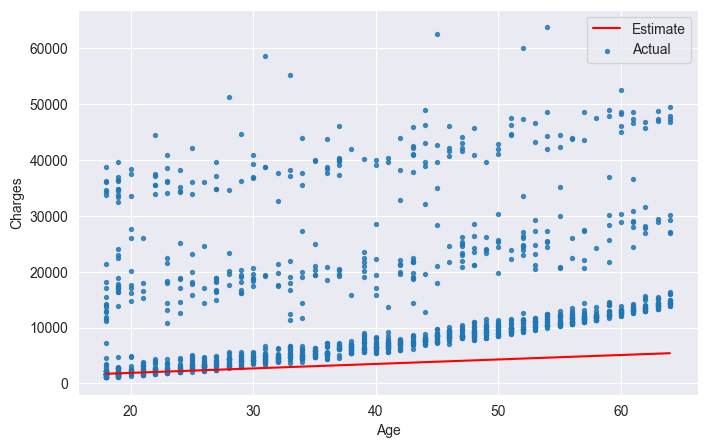

In [144]:
w = 80
b = 300

try_parameters(medical_df, w, b)

# початок лінії ок, потрібно пробувати інші параметри щоб підігнати кут нахилу

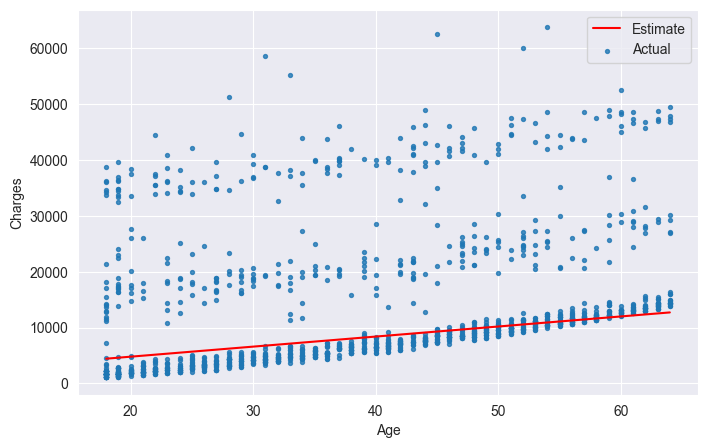

In [145]:
w = 180
b = 1200

try_parameters(medical_df, w, b)

# результат вже кращий, лінія проходить у тій зоні де загальна тенденція

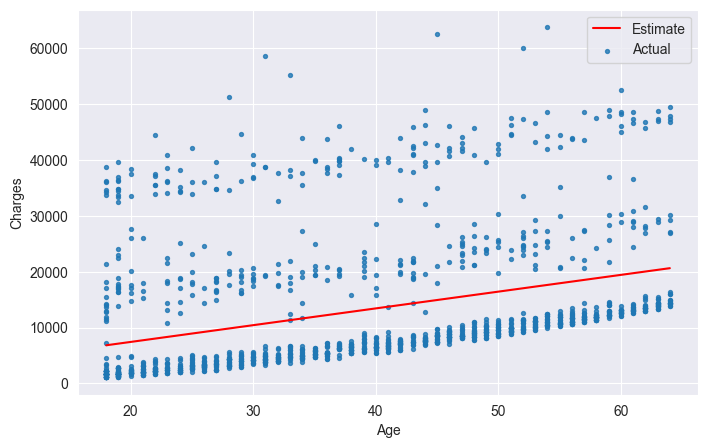

In [146]:
w = 300
b = 1440

try_parameters(medical_df, w, b)

# кут нахилу дуже схожий на заданий, є питання щодо початку прямої

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [147]:
import numpy as np
def get_rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

targets = non_smoker_df['charges']

In [152]:
w = 80
b = 300

estimated_charges = estimate_charges(non_smoker_df.age, w, b)
rmse = get_rmse(estimated_charges, targets)
print(rmse)

# loss = 7315, трохи краще ні ми отримали на лекції, проте модель прогнозує не дуже точно, продовжимо пошук

7315.833778481037


In [153]:
w = 180
b = 1200

estimated_charges = estimate_charges(non_smoker_df.age, w, b)
rmse = get_rmse(estimated_charges, targets)
print(rmse)

# loss = 4823, вже краще, модель все ще прогнозує не дуже точно, продовжимо пошук

4823.732550110848


In [154]:
w = 300
b = 1440

estimated_charges = estimate_charges(non_smoker_df.age, w, b)
rmse = get_rmse(estimated_charges, targets)
print(rmse)

# loss = 6722, рухаємось не в тому напрямку, продовжимо пошук

6722.85376453683


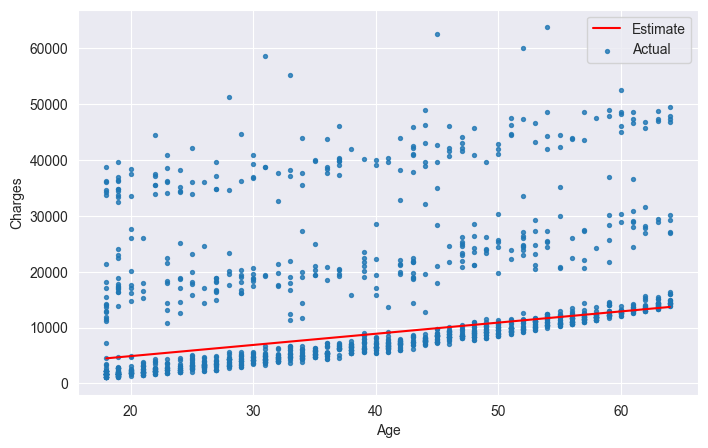

4769.970174814167


In [177]:
w = 200
b = 900

try_parameters(medical_df, w, b)

estimated_charges = estimate_charges(non_smoker_df.age, w, b)
rmse = get_rmse(estimated_charges, targets)
print(rmse)

In [ ]:
# методом багатьох спроб та помилок, вдалось знайти значення w і b, при яких loss становить близько 4770. Напевне було б корисно якось це автоматизувати, наприклад написати функцію яка б викликала rmse для певних діапазонів w і b.

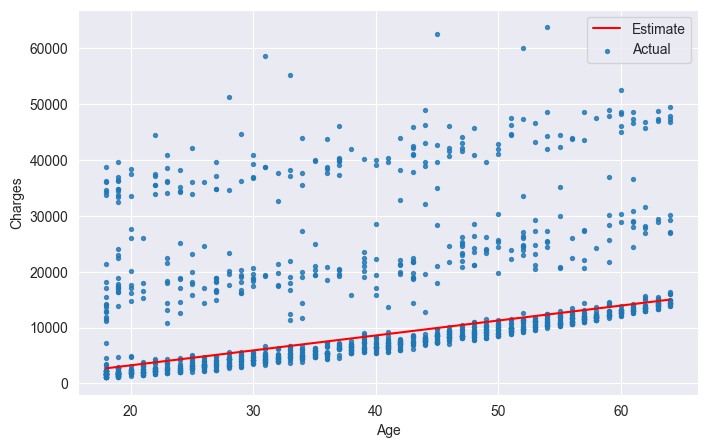

4662.50576663643


In [180]:
w = 267.2489
b = -2091.4206 

try_parameters(medical_df, w, b)

estimated_charges = estimate_charges(non_smoker_df.age, w, b)
rmse = get_rmse(estimated_charges, targets)
print(rmse)